# Credit Risk Prediction

In [ ]:
# import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Set plotting style
sns.set_style('whitegrid')

In [ ]:
try:
    train_df = pd.read_excel('/content/train-FIN_ANA_DATA .xls')
    test_df = pd.read_excel('/content/test-FIN_ANA_DATA .xls')
    print('Datasets loaded successfully.')
    print(f'Train data shape: {train_df.shape}')
    print(f'Test data shape: {test_df.shape}')
except Exception as e:
    print(f'Error loading datasets: {e}')

Datasets loaded successfully.
Train data shape: (37408, 11)
Test data shape: (4310, 11)


## 1. Exploratory Data Analysis (EDA)

Let's start by inspecting the first few rows of the training data, its information, and descriptive statistics.

### Merging Train and Test Data for Unified EDA

In [ ]:
# Concatenate the train and test dataframes
df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Merged data shape: {df.shape}')
print("Merged Data Head:")
display(df.head())

print("\nMerged Data Info:")
df.info()

print("\nMerged Data Description:")
display(df.describe(include='all'))

Merged data shape: (41718, 11)
Merged Data Head:


,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
0,27010017245,10720596,585913,M,F,0.0,0,N,Semi-urban,G,N
1,27010017436,43455000,585913,M,F,0.0,0,N,Semi-urban,G,N
2,27010017458,22012402,68348,M,F,0.0,2744483,N,Rural,G,N
3,27010017493,4893983,0,M,M,0.0,0,N,Semi-urban,G,N
4,27010017515,46254814,68348,M,F,0.0,0,N,Rural,G,N



Merged Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41718 entries, 0 to 41717
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ACC_NO                41718 non-null  int64  
 1   INVESTMENT_TOTAL      41718 non-null  int64  
 2   ACCCURRENTBALANCE     41718 non-null  int64  
 3   INF_MARITAL_STATUS    41716 non-null  object 
 4   INF_GENDER            41716 non-null  object 
 5   INSTALL_SIZE          40879 non-null  float64
 6   DUE_PAYMENT           41718 non-null  int64  
 7   COMPENSATION_CHARGED  41716 non-null  object 
 8   CLIENT_TYPE           41536 non-null  object 
 9   QUALITY_OF_LOAN       41718 non-null  object 
 10  REPAY_MODE            41718 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 3.5+ MB

Merged Data Description:


,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
count,4.171800e+04,4.171800e+04,4.171800e+04,41716,41716,4.087900e+04,4.171800e+04,41716,41536,41718,41718
unique,NaN,NaN,NaN,3,3,NaN,NaN,2,5,4,2
top,NaN,NaN,NaN,M,M,NaN,NaN,N,Rural,G,N
freq,NaN,NaN,NaN,39489,31411,NaN,NaN,24623,29306,37540,35345
mean,7.023571e+11,5.830303e+06,1.119271e+06,NaN,NaN,4.247588e+04,3.583429e+05,NaN,NaN,NaN,NaN
std,5.670841e+11,2.497411e+07,5.941019e+06,NaN,NaN,6.319890e+05,4.221569e+06,NaN,NaN,NaN,NaN
min,2.701002e+10,5.000890e+05,0.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN
25%,2.180500e+11,8.098830e+05,2.158000e+03,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN
50%,5.480900e+11,1.573405e+06,2.263300e+04,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN
75%,1.167820e+12,4.198347e+06,3.233320e+05,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN


In [ ]:
df["QUALITY_OF_LOAN"].unique()

array(['G', 'B', 'SS', 'DF'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41718 entries, 0 to 41717
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ACC_NO                41718 non-null  int64  
 1   INVESTMENT_TOTAL      41718 non-null  int64  
 2   ACCCURRENTBALANCE     41718 non-null  int64  
 3   INF_MARITAL_STATUS    41716 non-null  object 
 4   INF_GENDER            41716 non-null  object 
 5   INSTALL_SIZE          40879 non-null  float64
 6   DUE_PAYMENT           41718 non-null  int64  
 7   COMPENSATION_CHARGED  41716 non-null  object 
 8   CLIENT_TYPE           41536 non-null  object 
 9   QUALITY_OF_LOAN       41718 non-null  object 
 10  REPAY_MODE            41718 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 3.5+ MB


In [ ]:
df.isnull().sum()

,0
ACC_NO,0
INVESTMENT_TOTAL,0
ACCCURRENTBALANCE,0
INF_MARITAL_STATUS,2
INF_GENDER,2
INSTALL_SIZE,839
DUE_PAYMENT,0
COMPENSATION_CHARGED,2
CLIENT_TYPE,182
QUALITY_OF_LOAN,0


### client type and intsallment size has many missing values

In [ ]:
df.describe()

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INSTALL_SIZE,DUE_PAYMENT
count,4.171800e+04,4.171800e+04,4.171800e+04,4.087900e+04,4.171800e+04
mean,7.023571e+11,5.830303e+06,1.119271e+06,4.247588e+04,3.583429e+05
std,5.670841e+11,2.497411e+07,5.941019e+06,6.319890e+05,4.221569e+06
min,2.701002e+10,5.000890e+05,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.180500e+11,8.098830e+05,2.158000e+03,0.000000e+00,0.000000e+00
50%,5.480900e+11,1.573405e+06,2.263300e+04,0.000000e+00,0.000000e+00
75%,1.167820e+12,4.198347e+06,3.233320e+05,0.000000e+00,0.000000e+00
max,2.068490e+12,1.509387e+09,2.174153e+08,5.984437e+07,3.701924e+08


In [ ]:
df.columns

Index(['ACC_NO', 'INVESTMENT_TOTAL', 'ACCCURRENTBALANCE', 'INF_MARITAL_STATUS',
       'INF_GENDER', 'INSTALL_SIZE', 'DUE_PAYMENT', 'COMPENSATION_CHARGED',
       'CLIENT_TYPE', 'QUALITY_OF_LOAN', 'REPAY_MODE'],
      dtype='object')

In [ ]:

df.drop_duplicates(inplace=True)

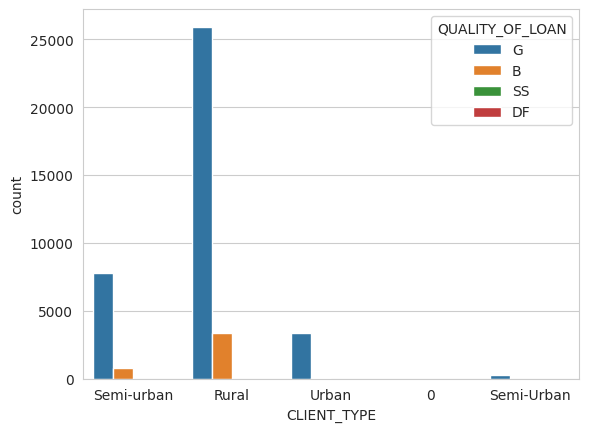

In [ ]:
sns.countplot(data=df, x="CLIENT_TYPE", hue="QUALITY_OF_LOAN")
plt.show()

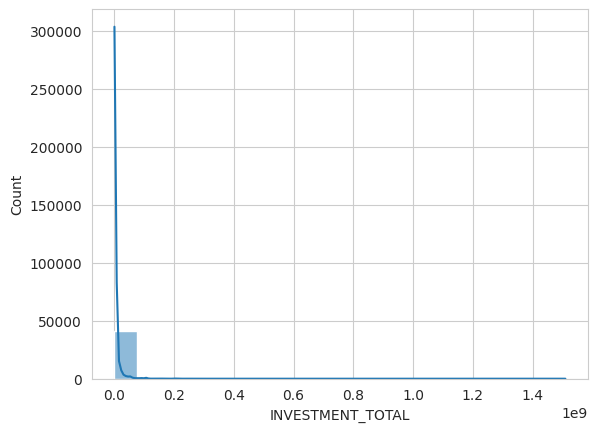

In [ ]:
sns.histplot(data=df, x="INVESTMENT_TOTAL", bins=20, kde=True)
plt.show()

In [ ]:
df["CLIENT_TYPE"] = df["CLIENT_TYPE"].fillna(df["CLIENT_TYPE"].mode()[0])

In [ ]:
df["INSTALL_SIZE"] = df["INSTALL_SIZE"].fillna(df["INSTALL_SIZE"].median())
df["INF_GENDER"] = df["INF_GENDER"].fillna(df["INF_GENDER"].mode()[0])

In [ ]:
df.isnull().sum()

,0
ACC_NO,0
INVESTMENT_TOTAL,0
ACCCURRENTBALANCE,0
INF_MARITAL_STATUS,2
INF_GENDER,0
INSTALL_SIZE,0
DUE_PAYMENT,0
COMPENSATION_CHARGED,2
CLIENT_TYPE,0
QUALITY_OF_LOAN,0


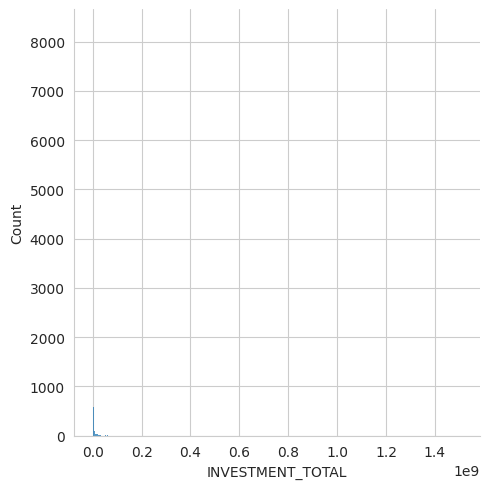

In [ ]:


sns.displot(x=df["INVESTMENT_TOTAL"])
plt.show()

In [ ]:
df["INVESTMENT_TOTAL"].skew()

np.float64(29.464530272223808)

**more people are from rural areas ,
there are more number of males than females,
more people are from rural areas,
more have good as their loan quality,  
more people are paying manually their repay mode ,  more people are not charged with compensation
there are many outliers in acurrentbalance and investment total**




# Univariate Analysis

<Axes: xlabel='INF_GENDER', ylabel='count'>

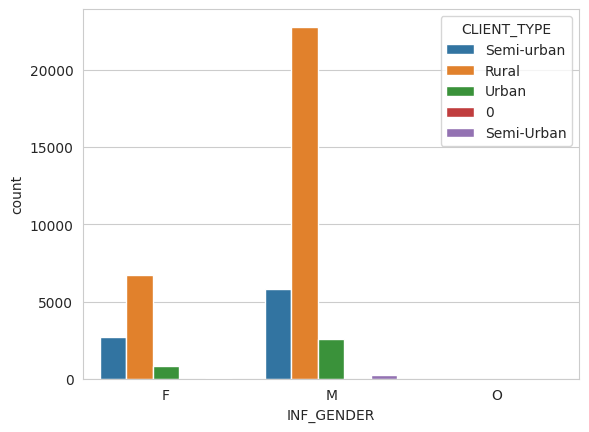

In [ ]:
sns.countplot(data=df, x="INF_GENDER",hue="CLIENT_TYPE")

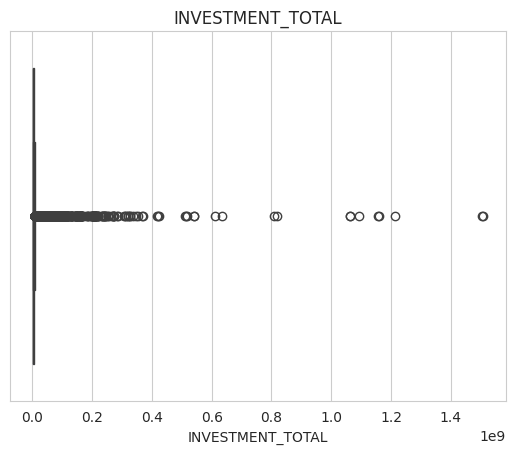

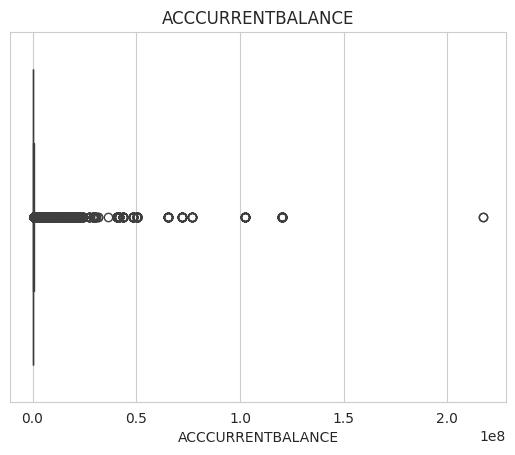

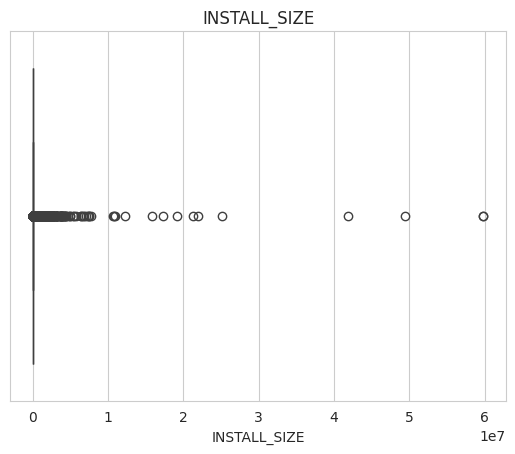

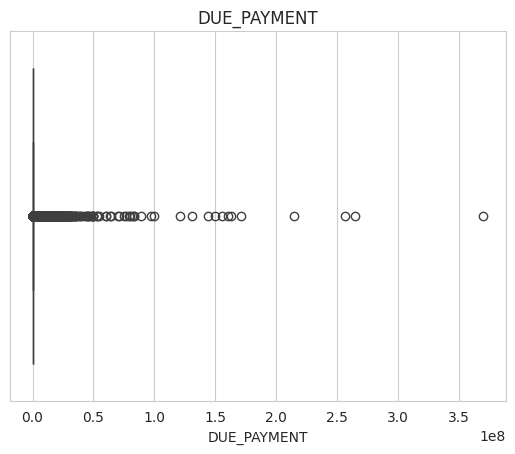

In [ ]:
cols = ['INVESTMENT_TOTAL',
        'ACCCURRENTBALANCE',
        'INSTALL_SIZE',
        'DUE_PAYMENT']
for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

<Axes: xlabel='INF_MARITAL_STATUS', ylabel='count'>

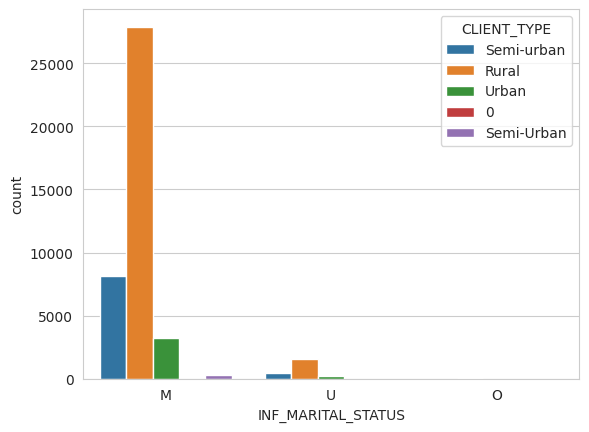

In [ ]:
sns.countplot(data=df, x="INF_MARITAL_STATUS",hue="CLIENT_TYPE")

<Axes: xlabel='QUALITY_OF_LOAN', ylabel='Count'>

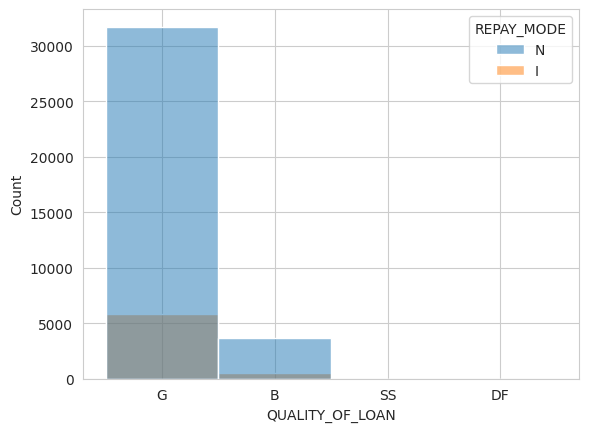

In [ ]:
sns.histplot(data=df, x="QUALITY_OF_LOAN",hue="REPAY_MODE")

<Axes: xlabel='REPAY_MODE', ylabel='count'>

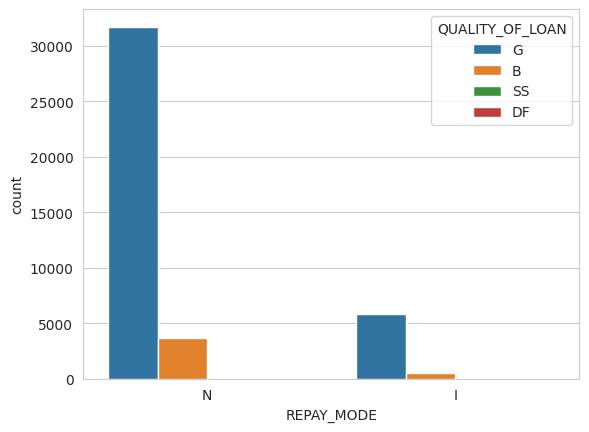

In [ ]:
sns.countplot(data=df, x="REPAY_MODE",hue="QUALITY_OF_LOAN")

<Axes: xlabel='COMPENSATION_CHARGED', ylabel='count'>

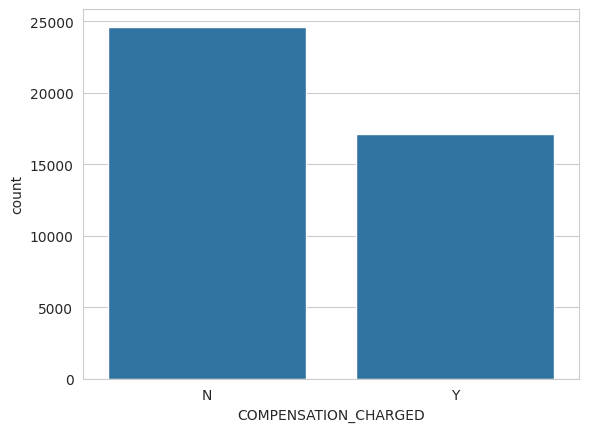

In [ ]:
sns.countplot(data=df, x="COMPENSATION_CHARGED")

In [ ]:
df.sample(15)

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
28247,918910000538,515993,62418,M,M,0.0,10211,Y,Rural,G,N
7131,157820024765,7591498,3970267,M,F,0.0,49123,Y,Rural,G,N
23613,648090072493,923250,151410,M,M,0.0,166750,N,Rural,G,N
18878,448350091287,654750,1695,M,M,0.0,0,Y,Rural,G,N
1923,29370006447,1906982,10051,M,F,14706.0,0,N,Urban,G,I
28029,898190000661,4339836,358604,M,F,0.0,0,Y,Rural,G,N
32834,1269410004234,11622500,0,M,F,22869.0,0,Y,Rural,G,I
26307,788090056737,6765750,2448,M,F,0.0,0,Y,Rural,G,N
40948,1928090000989,3315218,4754,M,M,0.0,0,N,Rural,G,N
7079,157810011016,19657500,318736,M,M,0.0,0,Y,Rural,B,N


<Axes: xlabel='ACCCURRENTBALANCE', ylabel='Density'>

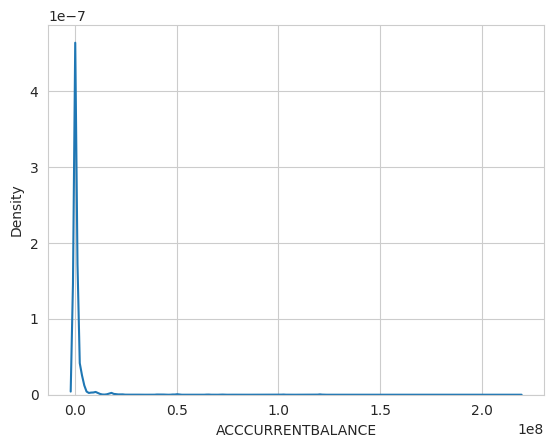

In [ ]:
sns.kdeplot(data=df,x="ACCCURRENTBALANCE")

In [ ]:
from sklearn.preprocessing import PowerTransformer

cols=['INVESTMENT_TOTAL',	'ACCCURRENTBALANCE','INSTALL_SIZE',	'DUE_PAYMENT']
for col in cols:

  pt = PowerTransformer(method='yeo-johnson')

  df[cols] = pt.fit_transform(df[cols])

In [ ]:
df[cols]

,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INSTALL_SIZE,DUE_PAYMENT
0,1.340904,0.917630,-0.438579,-0.439822
1,1.782348,0.917630,-0.438579,-0.439822
2,1.600484,0.242591,-0.438579,2.273648
3,0.946585,-2.313093,-0.438579,-0.439822
4,1.796576,0.242591,-0.438579,-0.439822
...,...,...,...,...
41713,0.539381,0.419055,-0.438579,-0.439822
41714,-1.606474,-1.610683,-0.438579,2.273648
41715,-1.512473,-1.178342,-0.438579,2.273648
41716,-1.511908,-2.313093,-0.438579,2.273648


In [ ]:
cols=['INVESTMENT_TOTAL',	'ACCCURRENTBALANCE','INSTALL_SIZE',	'DUE_PAYMENT']
for col in cols:
  print(df[col].skew())

0.00978582205404699
-0.052012118736058634
1.8415772682754519
1.833892450420669


<Axes: xlabel='INSTALL_SIZE', ylabel='INVESTMENT_TOTAL'>

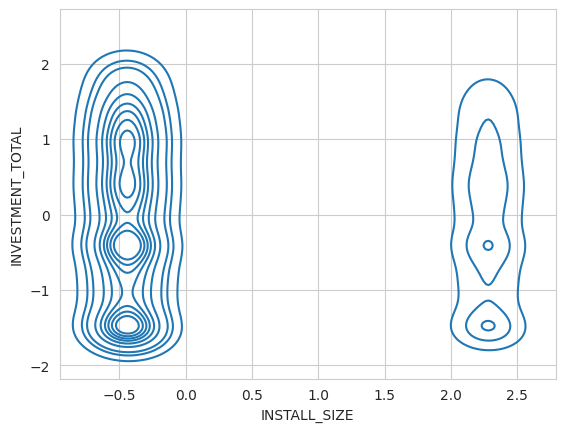

In [ ]:
sns.kdeplot(data=df,x="INSTALL_SIZE",y="INVESTMENT_TOTAL")

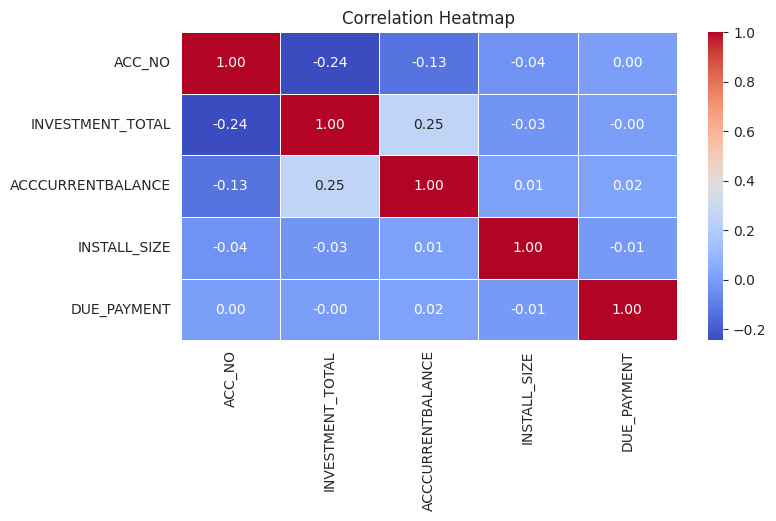

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

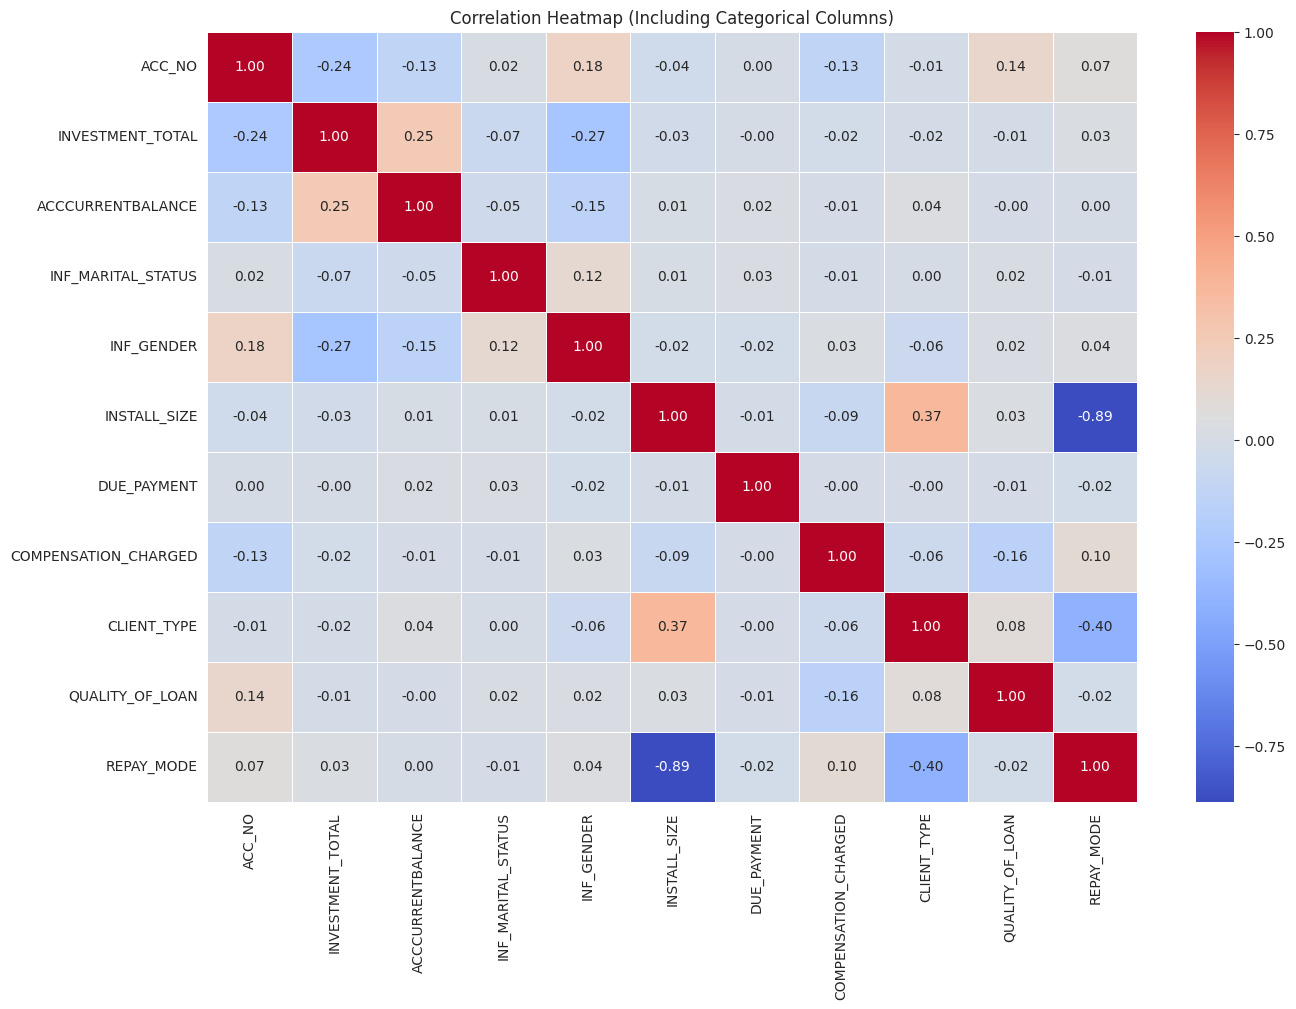

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr = df_encoded.corr()


plt.figure(figsize=(15 ,10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Including Categorical Columns)")
plt.show()

<Axes: xlabel='INSTALL_SIZE', ylabel='CLIENT_TYPE'>

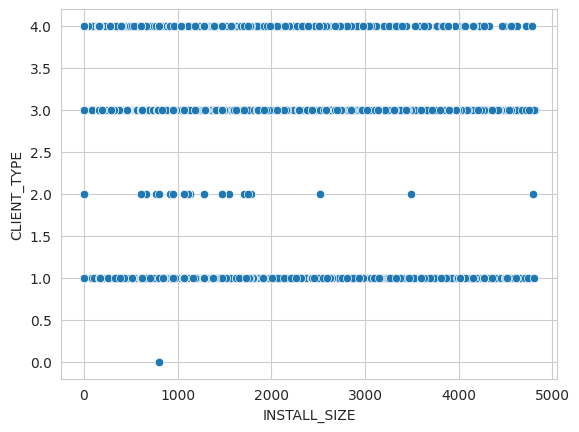

In [ ]:
df_encoded = df.copy()

# Encode all categorical columns
le = LabelEncoder()
df_encoded["INSTALL_SIZE"] = le.fit_transform(df_encoded["INSTALL_SIZE"].astype(str))


df_encoded["CLIENT_TYPE"] = le.fit_transform(df_encoded["CLIENT_TYPE"].astype(str))

sns.scatterplot(data=df_encoded,x="INSTALL_SIZE",y="CLIENT_TYPE")

<Axes: xlabel='INF_MARITAL_STATUS', ylabel='count'>

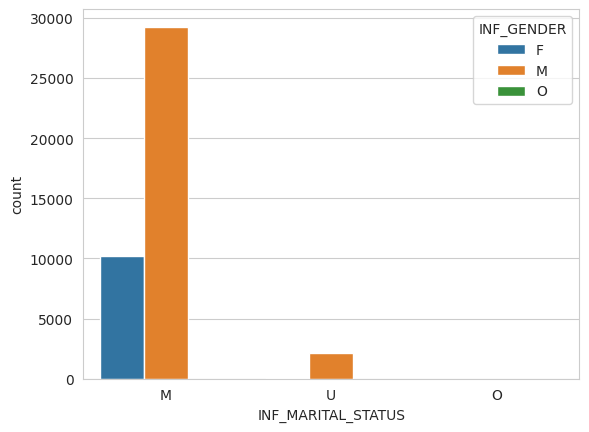

In [ ]:
sns.countplot(data=df_encoded,x="INF_MARITAL_STATUS",hue="INF_GENDER")

In [ ]:
df["INF_MARITAL_STATUS"].unique()

array(['M', 'U', 'O', nan], dtype=object)

# Extended EDA (Additional Analysis)

The section below adds a deeper, self-contained round of EDA on top of the analysis above. It reloads a fresh copy of the raw data (`df_eda`) so it doesn't interfere with `df`, which has already been cleaned and power-transformed earlier in this notebook.

In [ ]:

train_eda = pd.read_excel('/content/train-FIN_ANA_DATA .xls')
test_eda = pd.read_excel('/content/test-FIN_ANA_DATA .xls')
df_eda = pd.concat([train_eda, test_eda], ignore_index=True)

df_eda['IS_BAD'] = df_eda['QUALITY_OF_LOAN'].isin(['B', 'DF', 'SS']).astype(int)

print(f"Shape: {df_eda.shape}")
print(f"Overall bad-loan rate: {df_eda['IS_BAD'].mean()*100:.2f}%")
df_eda.head()

Shape: (41718, 12)
Overall bad-loan rate: 10.01%


,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE,IS_BAD
0,27010017245,10720596,585913,M,F,0.0,0,N,Semi-urban,G,N,0
1,27010017436,43455000,585913,M,F,0.0,0,N,Semi-urban,G,N,0
2,27010017458,22012402,68348,M,F,0.0,2744483,N,Rural,G,N,0
3,27010017493,4893983,0,M,M,0.0,0,N,Semi-urban,G,N,0
4,27010017515,46254814,68348,M,F,0.0,0,N,Rural,G,N,0


### Missing Values Overview

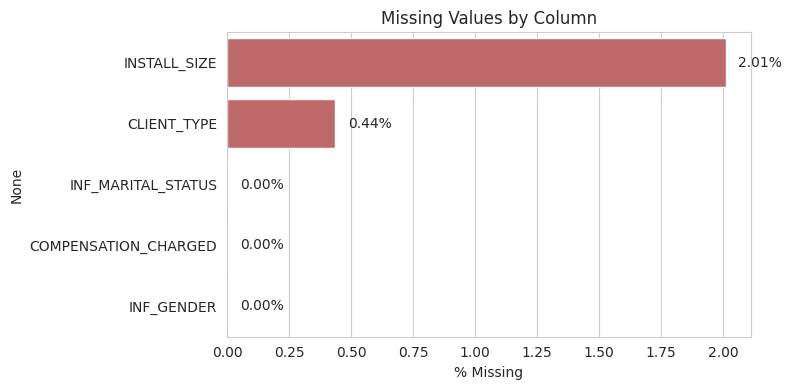

In [ ]:
missing = df_eda.isnull().sum()
missing_pct = (missing / len(df_eda) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color='indianred')
plt.xlabel('% Missing')
plt.title('Missing Values by Column')
for i, v in enumerate(missing_pct.values):
    plt.text(v + 0.05, i, f'{v:.2f}%', va='center')
plt.tight_layout()
plt.show()

### Data Quality Check — Inconsistent Categories

In [ ]:
print("CLIENT_TYPE raw categories:")
print(df_eda['CLIENT_TYPE'].value_counts(dropna=False))
print("\nQUALITY_OF_LOAN raw categories:")
print(df_eda['QUALITY_OF_LOAN'].value_counts(dropna=False))
print("\nINF_GENDER raw categories:")
print(df_eda['INF_GENDER'].value_counts(dropna=False))

CLIENT_TYPE raw categories:
CLIENT_TYPE
Rural         29306
Semi-urban     8529
Urban          3425
Semi-Urban      273
NaN             182
0                 3
Name: count, dtype: int64

QUALITY_OF_LOAN raw categories:
QUALITY_OF_LOAN
G     37540
B      4173
DF        4
SS        1
Name: count, dtype: int64

INF_GENDER raw categories:
INF_GENDER
M      31411
F      10303
NaN        2
O          2
Name: count, dtype: int64


### Target Variable: `QUALITY_OF_LOAN` Distribution (Class Imbalance)

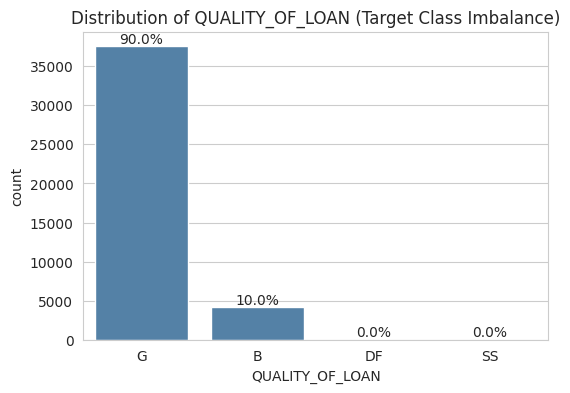

In [ ]:
plt.figure(figsize=(6, 4))
order = df_eda['QUALITY_OF_LOAN'].value_counts().index
ax = sns.countplot(data=df_eda, x='QUALITY_OF_LOAN', order=order, color='steelblue')
total = len(df_eda)
for p in ax.patches:
    pct = p.get_height() / total * 100
    ax.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.title('Distribution of QUALITY_OF_LOAN (Target Class Imbalance)')
plt.show()

### Outlier Detection (IQR Method) on Numerical Features

### Bad-Loan Rate by Categorical Features (Bivariate Analysis)

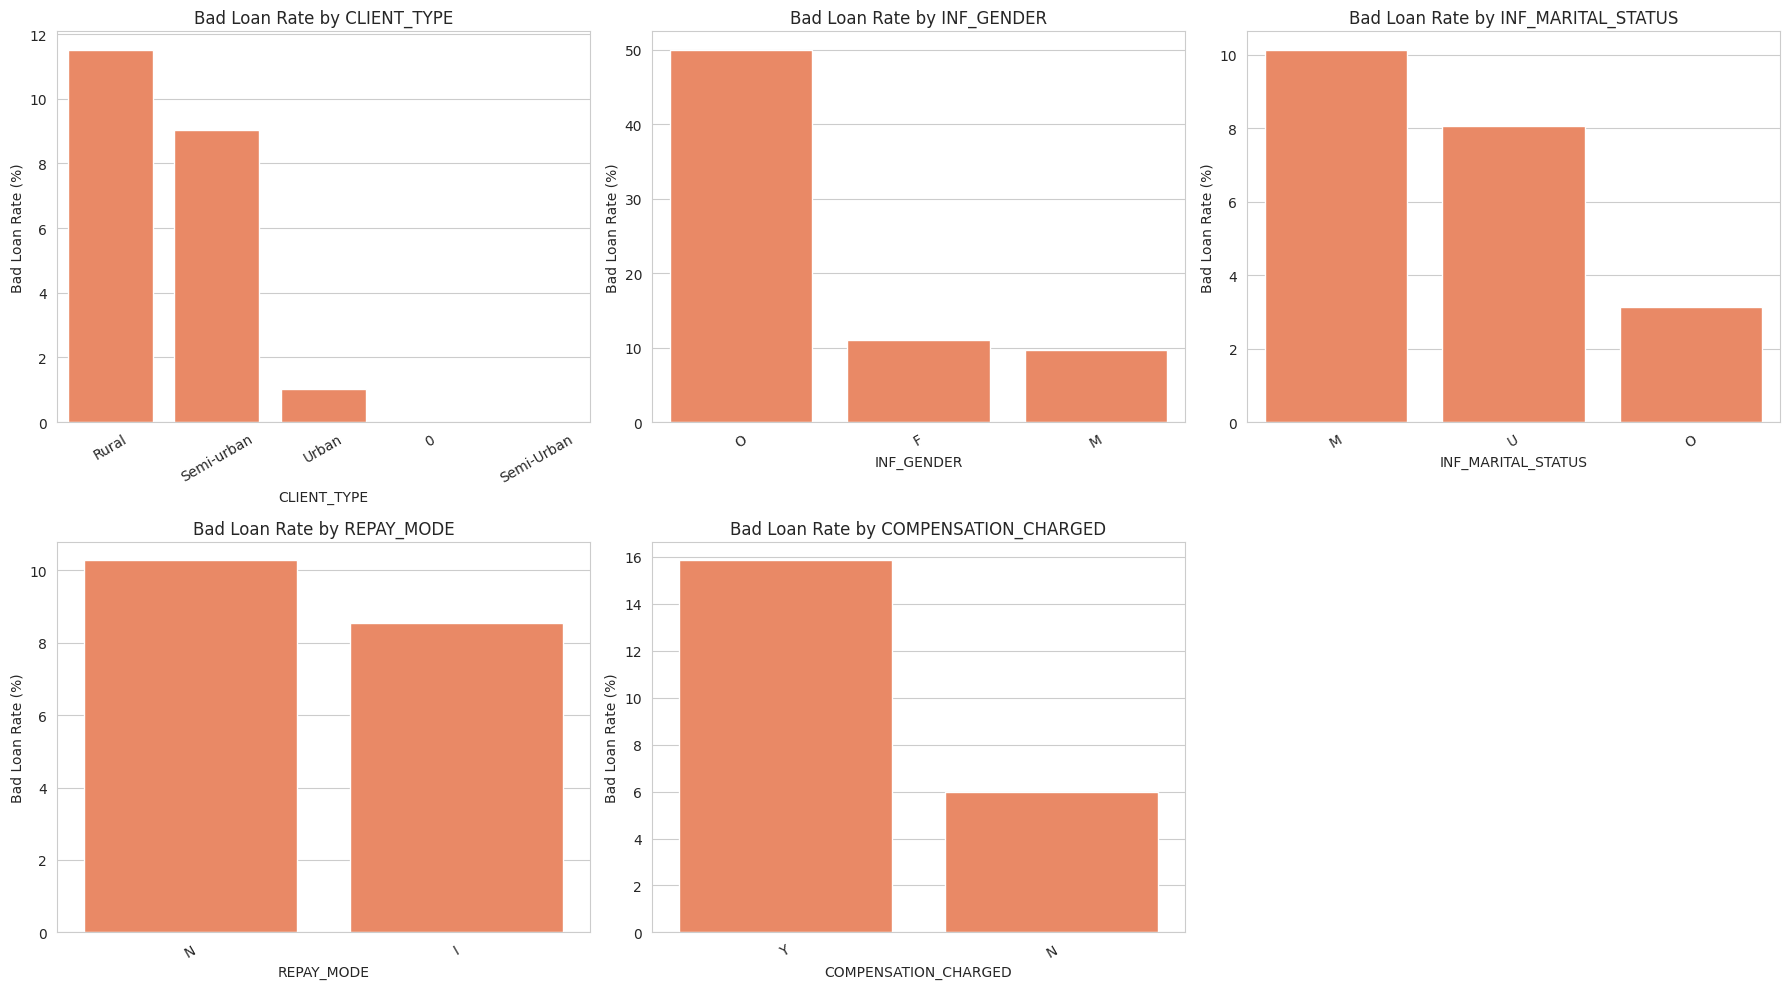

In [ ]:
cat_cols = ['CLIENT_TYPE', 'INF_GENDER', 'INF_MARITAL_STATUS', 'REPAY_MODE', 'COMPENSATION_CHARGED']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    rate = (df_eda.groupby(col)['IS_BAD'].mean().sort_values(ascending=False) * 100)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color='coral')
    ax.set_ylabel('Bad Loan Rate (%)')
    ax.set_title(f'Bad Loan Rate by {col}')
    ax.tick_params(axis='x', rotation=30)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

### Numerical Feature Distributions Split by Loan Quality

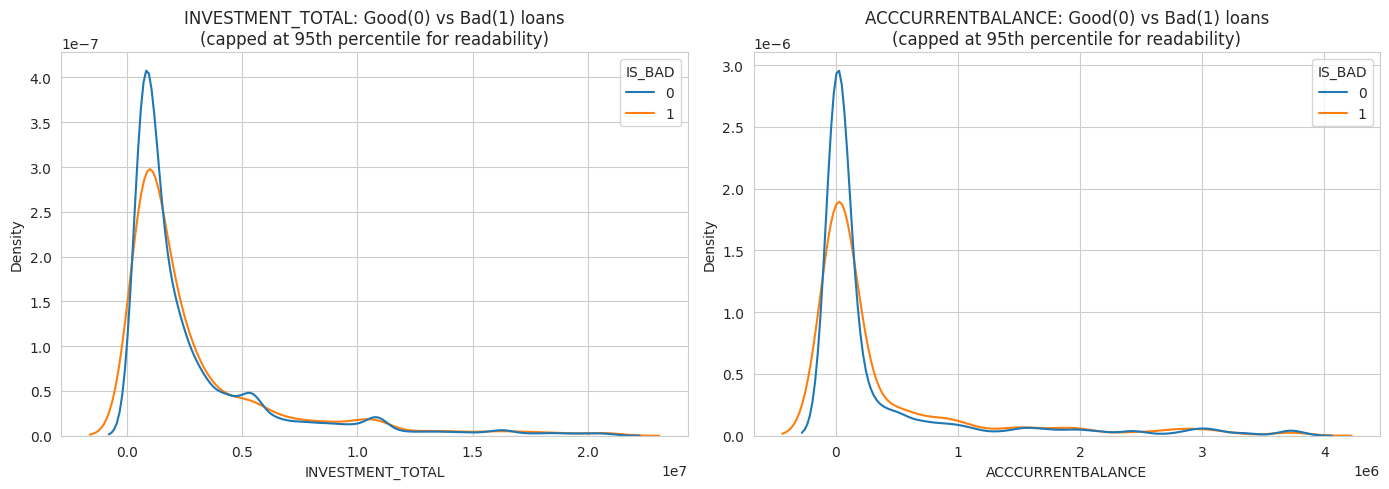

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

inv_cap = df_eda['INVESTMENT_TOTAL'].quantile(0.95)
sns.kdeplot(data=df_eda[df_eda['INVESTMENT_TOTAL'] <= inv_cap], x='INVESTMENT_TOTAL',
            hue='IS_BAD', common_norm=False, ax=axes[0])
axes[0].set_title('INVESTMENT_TOTAL: Good(0) vs Bad(1) loans\n(capped at 95th percentile for readability)')

bal_cap = df_eda['ACCCURRENTBALANCE'].quantile(0.95)
sns.kdeplot(data=df_eda[df_eda['ACCCURRENTBALANCE'] <= bal_cap], x='ACCCURRENTBALANCE',
            hue='IS_BAD', common_norm=False, ax=axes[1])
axes[1].set_title('ACCCURRENTBALANCE: Good(0) vs Bad(1) loans\n(capped at 95th percentile for readability)')

plt.tight_layout()
plt.show()

### Correlation Heatmap — Numerical Features vs Target

In [ ]:
num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()

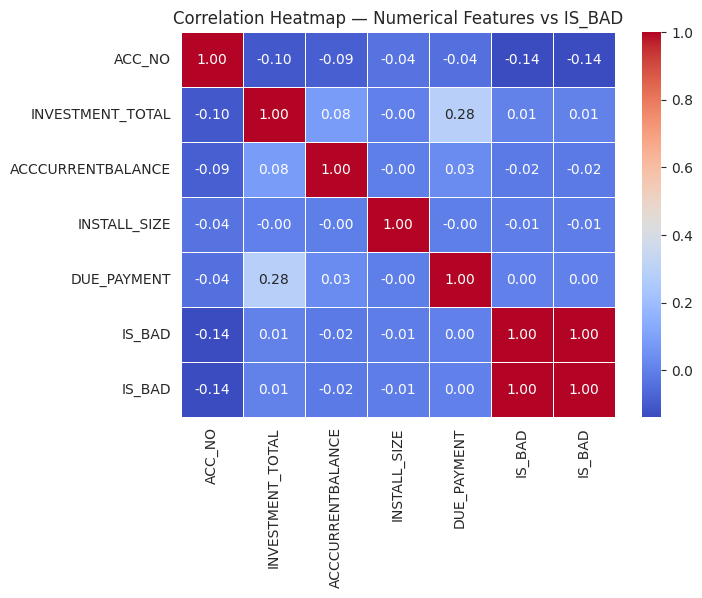

In [ ]:
num_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
num_with_target = num_cols + ['IS_BAD']
plt.figure(figsize=(7, 5))
sns.heatmap(df_eda[num_with_target].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features vs IS_BAD')
plt.show()

## EDA Insights Summary

**Dataset & target**
- The merged dataset has 41,718 rows and 11 columns (37,408 train + 4,310 test).
- The target `QUALITY_OF_LOAN` is heavily imbalanced: **G (good) = 89.9%**, **B (bad) = 10.0%**, with `DF` and `SS` each making up a negligible fraction (4 and 1 rows). Overall bad-loan rate (B/DF/SS combined) is **~10.0%**. This imbalance means accuracy alone will be a misleading metric for any classifier built on this data — precision/recall, F1, or ROC-AUC (and possibly resampling/class weights) should be used instead.

**Missing values**
- `INSTALL_SIZE` has the most missing values (839 rows, ~2%), followed by `CLIENT_TYPE` (182 rows, ~0.4%). `INF_MARITAL_STATUS`, `INF_GENDER`, and `COMPENSATION_CHARGED` each have only 2 missing rows. Volumes are small enough that simple imputation (median/mode, as already done above) is reasonable, but `INSTALL_SIZE` missingness is worth flagging as its own indicator feature if it's used for modeling later.

**Data quality issues found**
- `CLIENT_TYPE` contains inconsistent category labels that should be standardized before modeling: `"Semi-urban"` (8,529 rows) and `"Semi-Urban"` (273 rows) are the same category with different casing, and there are 3 rows with a stray literal value `0`. These should be merged/cleaned (e.g., `.str.strip().str.title()` plus dropping/fixing the `0` rows) — otherwise the model will treat them as separate categories.
- `INF_GENDER` has a rare `'O'` category with only 2 rows — too few to draw any reliable conclusion, and its 50% bad-loan rate seen in bivariate analysis is not statistically meaningful (just 1 of 2 rows).

**Outliers**
- All four numeric columns show substantial outliers under the IQR rule: `ACCCURRENTBALANCE` (~17.6%), `DUE_PAYMENT` (~16.2%), `INSTALL_SIZE` (~16.1%), and `INVESTMENT_TOTAL` (~12.0%). These aren't necessarily data errors — large investment/balance amounts are plausible in a lending context — but the extreme right-skew (`INVESTMENT_TOTAL` skew ≈ 29.5 before any transform) confirms the Yeo-Johnson power transform applied later in the notebook is well justified for these features.

**Bivariate relationships with loan quality**
- `COMPENSATION_CHARGED` shows the clearest signal: customers charged compensation have a notably higher bad-loan rate (~15.9%) than those who weren't (~6.0%) — this is one of the strongest simple predictors in the dataset.
- `CLIENT_TYPE` matters too: **Rural** clients have the highest bad-loan rate (~11.5%), **Semi-urban** is lower (~9.0%), and **Urban** clients are markedly safer (~1.0%).
- `REPAY_MODE`: manual repayment (`N`) has a slightly higher bad-loan rate (~10.3%) than institutional/automated repayment (`I`, ~8.6%).
- `INF_MARITAL_STATUS` and `INF_GENDER` show smaller differences and, for the rarer categories (`O`), the sample sizes are too small to generalize confidently.

**Correlations**
- None of the four numeric features (`INVESTMENT_TOTAL`, `ACCCURRENTBALANCE`, `INSTALL_SIZE`, `DUE_PAYMENT`) correlate strongly (linearly) with the bad-loan target — all correlations are below 0.02 in magnitude. This suggests the numeric features alone don't linearly separate good vs. bad loans well; the categorical features (`COMPENSATION_CHARGED`, `CLIENT_TYPE`) appear more informative for this problem, and non-linear models (tree-based methods) may capture numeric-feature effects better than linear ones.

**Overall takeaway for modeling**
- Clean the `CLIENT_TYPE` category inconsistency before encoding.
- Treat class imbalance explicitly (class weights, SMOTE, or threshold tuning) given the ~90/10 split.
- Prioritize `COMPENSATION_CHARGED`, `CLIENT_TYPE`, and `REPAY_MODE` as likely strong categorical predictors; numeric features may need interaction terms or non-linear models to be useful given their weak linear correlation with the target.


In [ ]:
cols = ['INVESTMENT_TOTAL',
        'ACCCURRENTBALANCE',
        'INSTALL_SIZE',
        'DUE_PAYMENT']

for col in cols:
    Q1 = df[col].quantile(0.15)
    Q3 = df[col].quantile(0.85)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [ ]:

# from sklearn.preprocessing import PowerTransformer

# cols = ['INVESTMENT_TOTAL',
#         'ACCCURRENTBALANCE',
#         'INSTALL_SIZE',
#         'DUE_PAYMENT']

# pt = PowerTransformer(method='yeo-johnson')

# df[cols] = pt.fit_transform(df[cols])

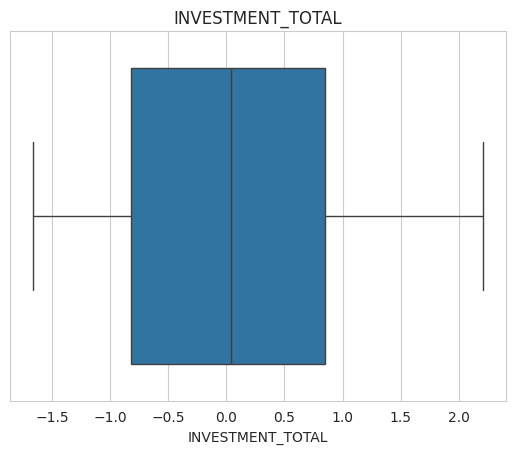

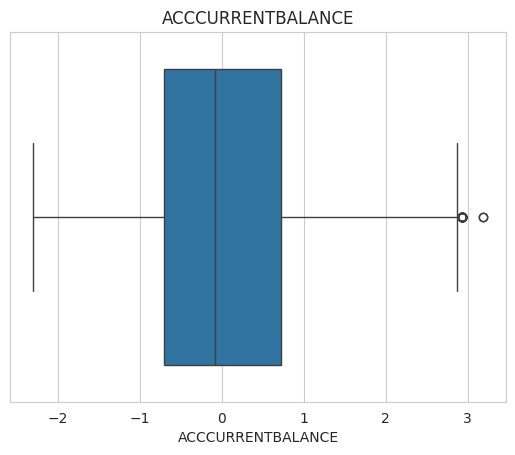

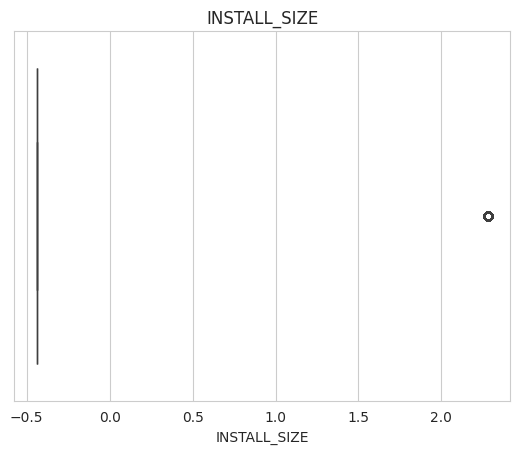

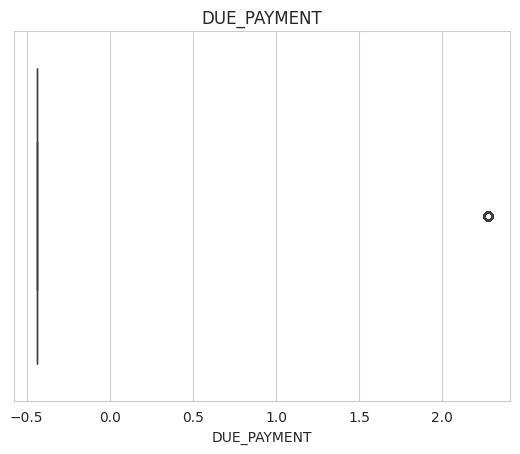

In [ ]:
cols = ['INVESTMENT_TOTAL',
        'ACCCURRENTBALANCE',
        'INSTALL_SIZE',
        'DUE_PAYMENT']
for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

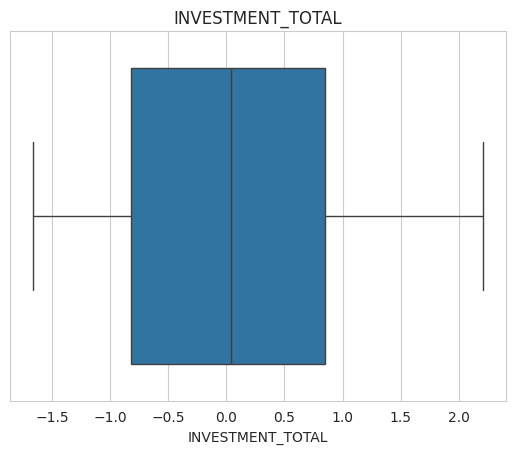

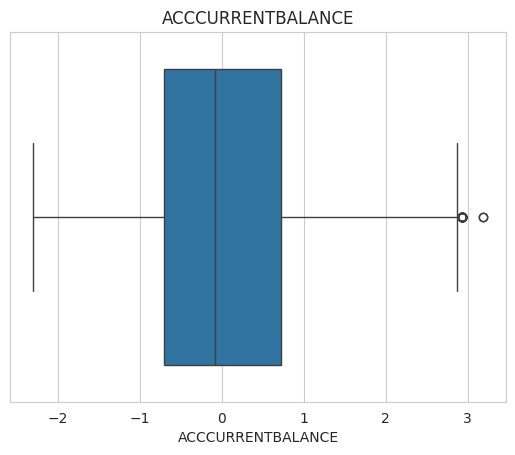

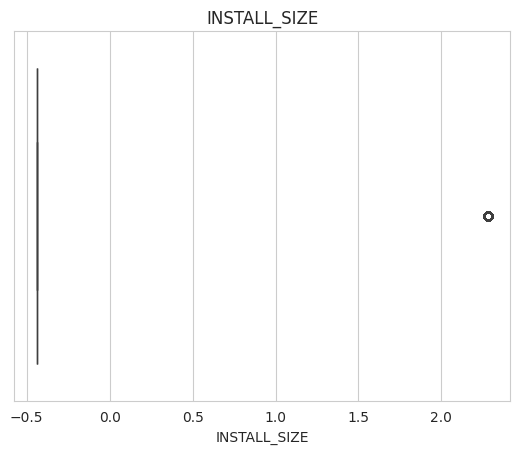

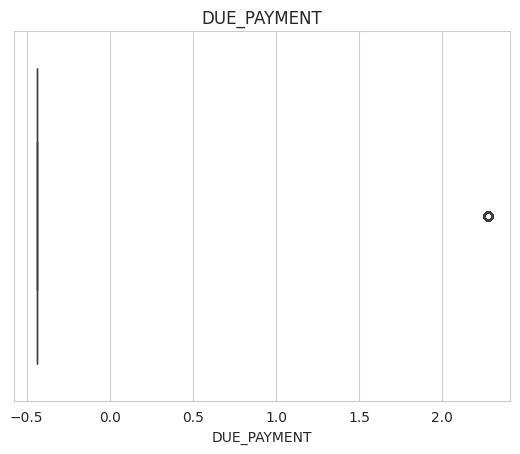

In [ ]:
cols = ['INVESTMENT_TOTAL',
        'ACCCURRENTBALANCE',
        'INSTALL_SIZE',
        'DUE_PAYMENT']
for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
df.head()

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
0,27010017245,1.340904,0.917630,M,F,-0.438579,-0.439822,N,Semi-urban,G,N
1,27010017436,1.782348,0.917630,M,F,-0.438579,-0.439822,N,Semi-urban,G,N
2,27010017458,1.600484,0.242591,M,F,-0.438579,2.273648,N,Rural,G,N
3,27010017493,0.946585,-2.313093,M,M,-0.438579,-0.439822,N,Semi-urban,G,N
4,27010017515,1.796576,0.242591,M,F,-0.438579,-0.439822,N,Rural,G,N


In [ ]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "INF_GENDER","COMPENSATION_CHARGED",
    "INF_MARITAL_STATUS","QUALITY_OF_LOAN",
    "CLIENT_TYPE",
    "REPAY_MODE"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df.sample(10)

,ACC_NO,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
2490,38090052943,0.399994,-0.336313,0,1,-0.438579,-0.439822,1,1,0,1
22038,568090063551,-1.005253,-0.678218,0,1,-0.438579,-0.439822,0,4,2,1
4597,97820020393,0.362935,-0.265207,2,1,-0.438579,2.273648,0,1,2,1
17210,388350073099,-0.390269,-0.626502,0,1,-0.438579,-0.439822,0,1,2,1
23141,608350047141,-0.333520,-0.965463,0,1,2.280090,-0.439822,0,3,2,0
22373,568350129812,0.081039,-0.402962,0,1,-0.438579,-0.439822,0,1,2,1
30245,1058190000703,-1.542289,-0.777547,0,1,-0.438579,-0.439822,0,1,2,1
25393,748030001151,1.009972,-0.826825,0,0,-0.438579,-0.439822,1,1,2,1
16866,379130000059,1.518235,0.222324,0,1,-0.438579,-0.439822,1,1,0,1
17369,398090021768,0.357261,-0.902553,0,1,2.280090,-0.439822,0,1,2,0


In [ ]:
x = pd.concat([df.iloc[:,1:8], df.iloc[:,10]], axis=1)
y = df.iloc[:, 9]

In [ ]:
x


,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,REPAY_MODE
0,1.340904,0.917630,0,0,-0.438579,-0.439822,0,1
1,1.782348,0.917630,0,0,-0.438579,-0.439822,0,1
2,1.600484,0.242591,0,0,-0.438579,2.273648,0,1
3,0.946585,-2.313093,0,1,-0.438579,-0.439822,0,1
4,1.796576,0.242591,0,0,-0.438579,-0.439822,0,1
...,...,...,...,...,...,...,...,...
41713,0.539381,0.419055,0,1,-0.438579,-0.439822,0,1
41714,-1.606474,-1.610683,0,1,-0.438579,2.273648,0,0
41715,-1.512473,-1.178342,0,1,-0.438579,2.273648,0,0
41716,-1.511908,-2.313093,0,1,-0.438579,2.273648,0,0


In [ ]:
y

,QUALITY_OF_LOAN
0,2
1,2
2,2
3,2
4,2
...,...
41713,2
41714,2
41715,2
41716,2


In [ ]:
from sklearn.model_selection import train_test_split
xtr,xte,ytr,yte=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
xte

,INVESTMENT_TOTAL,ACCCURRENTBALANCE,INF_MARITAL_STATUS,INF_GENDER,INSTALL_SIZE,DUE_PAYMENT,COMPENSATION_CHARGED,CLIENT_TYPE,QUALITY_OF_LOAN,REPAY_MODE
20930,0.876376,-0.050881,0,1,-0.438579,-0.439822,1,1,2,1
35237,1.279661,1.475490,0,0,-0.438579,-0.439822,0,1,2,1
36850,-0.358107,0.041589,0,1,-0.438579,2.273648,1,4,2,1
33775,-1.496501,-0.178455,0,1,2.280090,-0.439822,0,1,2,0
28209,0.863761,1.466265,0,1,-0.438579,-0.439822,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...
20663,0.357261,0.187968,0,1,-0.438579,-0.439822,1,1,2,1
11993,1.711821,1.344216,0,0,-0.438579,-0.439822,0,3,2,1
11096,-0.376040,1.292671,0,1,2.280090,-0.439822,1,3,2,0
38527,-0.705027,-1.008791,0,1,-0.438579,-0.439822,0,1,2,1


In [ ]:
yte

,QUALITY_OF_LOAN
20930,2
35237,2
36850,2
33775,2
28209,2
...,...
20663,2
11993,2
11096,2
38527,2


In [ ]:
ytr

,QUALITY_OF_LOAN
36075,2
20646,2
30969,2
30214,2
6668,0
...,...
31019,2
30280,2
6637,2
35343,2


In [ ]:
!pip install xgboost
from xgboost import XGBClassifier
model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

In [ ]:
model.fit(xtr, ytr)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:

y_pred = model.predict(xte)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(yte, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(yte, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       795
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00      7548

    accuracy                           1.00      8344
   macro avg       1.00      1.00      1.00      8344
weighted avg       1.00      1.00      1.00      8344



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yte, y_pred)
print(cm)

[[ 795    0    0]
 [   0    1    0]
 [   0    0 7548]]
